# 06 — Statistical Significance Testing

**Post-hoc analysis on existing JSONL prediction files — zero re-inference.**

This notebook computes and visualises:
- **Bootstrap 95% Confidence Intervals** (n=10,000 resamples) for Token F1 and Judge Accuracy per model per dataset
- **Pairwise Paired Permutation Tests** (n=10,000 permutations, two-sided) for every model pair on SLAKE and VQA-RAD
- **CI Bar Charts** — F1 and Judge Acc with error bars
- **P-value Heatmaps** — colour-coded significance matrices
- **Significance Delta Heatmaps** — ΔF1 annotated with p-value stars

---
| Dataset | Models | n |
|---|---|---|
| SLAKE | MedGemma-4B · Gemma-3-4B · HuatuoGPT-7B · LLaVA-1.6-7B · LLaVA-Med-7B | 1,061 |
| VQA-RAD | MedGemma-4B · Gemma-3-4B · HuatuoGPT-7B · LLaVA-1.6-7B · LLaVA-Med-7B | 451 |
| VQAv2 | Gemma-3-4B · LLaVA-1.6-7B | 1,000 |
| OK-VQA | Gemma-3-4B · LLaVA-1.6-7B | 1,000 |

In [1]:
import json
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from itertools import combinations

warnings.filterwarnings('ignore')

# ── Paths (notebook lives in notebooks/, data is one level up) ───────────────
ROOT        = Path('..').resolve()
INFERENCE   = ROOT / 'outputs' / 'inference'
JUDGE       = ROOT / 'outputs' / 'judge'
RESULTS_DIR = ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 140,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
})

# ── Colour palette (one colour per model, consistent across all plots) ────────
MODEL_COLORS = {
    'MedGemma-4B':  '#1d6fa4',
    'HuatuoGPT-7B': '#e07b39',
    'Gemma-3-4B':   '#4caf7d',
    'LLaVA-Med-7B': '#9c6ade',
    'LLaVA-1.6-7B': '#d94f4f',
}

print('✓ Environment ready.')
print(f'  INFERENCE: {INFERENCE}')
print(f'  JUDGE:     {JUDGE}')

✓ Environment ready.
  INFERENCE: /Users/shriyanshraj/vlm_benchmark/outputs/inference
  JUDGE:     /Users/shriyanshraj/vlm_benchmark/outputs/judge


## 1. Metric Functions

All metrics mirror the **v2 evaluation protocol** documented in `docs/report.md §4`.

In [2]:
def normalize(text: str) -> list:
    """Lowercase, strip punctuation, tokenize."""
    text = text.lower().strip().translate(str.maketrans('', '', string.punctuation))
    return text.split()

def token_f1(pred: str, gt: str) -> float:
    p, g = normalize(pred), normalize(gt)
    if not p or not g:
        return 0.0
    common = set(p) & set(g)
    if not common:
        return 0.0
    prec = len(common) / len(p)
    rec  = len(common) / len(g)
    return 2 * prec * rec / (prec + rec)

def bootstrap_ci(scores: np.ndarray, n: int = 10_000, ci: float = 0.95, seed: int = 42):
    """Returns (mean, lower, upper) as percentages."""
    if len(scores) == 0:
        return (0.0, 0.0, 0.0)
    rng = np.random.default_rng(seed)
    means = np.array([
        rng.choice(scores, size=len(scores), replace=True).mean()
        for _ in range(n)
    ])
    alpha = (1 - ci) / 2
    mean  = float(np.mean(scores)) * 100
    lower = float(np.percentile(means, alpha * 100)) * 100
    upper = float(np.percentile(means, (1 - alpha) * 100)) * 100
    return mean, lower, upper

def paired_permutation_test(a: np.ndarray, b: np.ndarray, n: int = 10_000, seed: int = 42) -> float:
    """Two-sided paired permutation test. Returns p-value."""
    rng = np.random.default_rng(seed)
    min_len = min(len(a), len(b))
    a, b = a[:min_len], b[:min_len]
    observed = abs(np.mean(a) - np.mean(b))
    diffs = a - b
    count = sum(
        abs(np.mean(rng.choice([-1, 1], size=len(diffs)) * diffs)) >= observed
        for _ in range(n)
    )
    return count / n

def stars(p: float) -> str:
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

print('✓ Metric functions defined.')

✓ Metric functions defined.


## 2. Load Data & Compute Per-Sample Scores

In [3]:
# ── File registry: (display_name, inference_file, judge_file) ─────────────────
DATASETS = {
    'SLAKE': [
        ('MedGemma-4B',
         INFERENCE / 'google_medgemma-4b-it__slake_v2.jsonl',
         JUDGE     / 'google_medgemma-4b-it__slake_v2_judged.jsonl'),
        ('Gemma-3-4B',
         INFERENCE / 'google_gemma-3-4b-it__slake_v2.jsonl',
         JUDGE     / 'google_gemma-3-4b-it__slake_v2_judged.jsonl'),
        ('HuatuoGPT-7B',
         INFERENCE / 'FreedomIntelligence_HuatuoGPT-Vision-7B-Qwen2.5VL__slake_7b_v2.jsonl',
         JUDGE     / 'FreedomIntelligence_HuatuoGPT-Vision-7B-Qwen2.5VL__slake_7b_v2_judged.jsonl'),
        ('LLaVA-1.6-7B',
         INFERENCE / 'llava-hf_llava-v1.6-mistral-7b-hf__slake_7b_v2.jsonl',
         JUDGE     / 'llava-hf_llava-v1.6-mistral-7b-hf__slake_7b_v2_judged.jsonl'),
        ('LLaVA-Med-7B',
         INFERENCE / 'microsoft_llava-med-v1.5-mistral-7b__slake_7b_v2-2.jsonl',
         JUDGE     / 'microsoft_llava-med-v1.5-mistral-7b__slake_7b_v2-2_judged.jsonl'),
    ],
    'VQA-RAD': [
        ('MedGemma-4B',
         INFERENCE / 'google_medgemma-4b-it__vqa_rad_v2.jsonl',
         JUDGE     / 'google_medgemma-4b-it__vqa_rad_v2_judged.jsonl'),
        ('Gemma-3-4B',
         INFERENCE / 'google_gemma-3-4b-it__vqa_rad_v2.jsonl',
         JUDGE     / 'google_gemma-3-4b-it__vqa_rad_v2_judged.jsonl'),
        ('HuatuoGPT-7B',
         INFERENCE / 'FreedomIntelligence_HuatuoGPT-Vision-7B-Qwen2.5VL__vqa_rad_7b_v2.jsonl',
         JUDGE     / 'FreedomIntelligence_HuatuoGPT-Vision-7B-Qwen2.5VL__vqa_rad_7b_v2_judged.jsonl'),
        ('LLaVA-1.6-7B',
         INFERENCE / 'llava-hf_llava-v1.6-mistral-7b-hf__vqa_rad_7b_v2.jsonl',
         JUDGE     / 'llava-hf_llava-v1.6-mistral-7b-hf__vqa_rad_7b_v2_judged.jsonl'),
        ('LLaVA-Med-7B',
         INFERENCE / 'microsoft_llava-med-v1.5-mistral-7b__vqa_rad_7b_v2.jsonl',
         JUDGE     / 'microsoft_llava-med-v1.5-mistral-7b__vqa_rad_7b_v2_judged.jsonl'),
    ],
    'VQAv2': [
        ('Gemma-3-4B',
         INFERENCE / 'google_gemma-3-4b-it__vqav2_v2.jsonl',
         JUDGE     / 'google_gemma-3-4b-it__vqav2_v2_judged.jsonl'),
        ('LLaVA-1.6-7B',
         INFERENCE / 'llava-hf_llava-v1.6-mistral-7b-hf__vqav2_v2.jsonl',
         JUDGE     / 'llava-hf_llava-v1.6-mistral-7b-hf__vqav2_v2_judged.jsonl'),
    ],
    'OK-VQA': [
        ('Gemma-3-4B',
         INFERENCE / 'google_gemma-3-4b-it__okvqa_v2.jsonl',
         JUDGE     / 'google_gemma-3-4b-it__okvqa_v2_judged.jsonl'),
        ('LLaVA-1.6-7B',
         INFERENCE / 'llava-hf_llava-v1.6-mistral-7b-hf__okvqa_v2.jsonl',
         JUDGE     / 'llava-hf_llava-v1.6-mistral-7b-hf__okvqa_v2_judged.jsonl'),
    ],
}

In [4]:
def load_jsonl(path):
    records = []
    with open(path, encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return sorted(records, key=lambda r: r['idx'])

def compute_scores(inf_path, judge_path):
    records = load_jsonl(inf_path)
    f1_all = []
    for r in records:
        f1_all.append(token_f1(str(r.get('prediction','') or ''),
                                str(r.get('ground_truth','') or '')))

    judge_correct = None
    if judge_path and judge_path.exists():
        judged  = load_jsonl(judge_path)
        inf_idx = {r['idx'] for r in records}
        judge_correct = np.array([
            1.0 if float(j.get('judge_score', 0) or 0) >= 4 else 0.0
            for j in judged if j['idx'] in inf_idx
        ])
    return np.array(f1_all), judge_correct, len(records)

# ── Load everything ───────────────────────────────────────────────────────────
ALL_SCORES = {}   # {dataset: {model: {'f1': array, 'judge': array, 'n': int}}}

for dataset, file_list in DATASETS.items():
    ALL_SCORES[dataset] = {}
    for name, inf_file, judge_file in file_list:
        if not inf_file.exists():
            print(f'  [MISSING] {name} / {dataset}: {inf_file.name}')
            continue
        f1, judge, n = compute_scores(inf_file, judge_file)
        ALL_SCORES[dataset][name] = {'f1': f1, 'judge': judge, 'n': n}
        m = f1.mean() * 100
        j = f'Judge={judge.mean()*100:.1f}%' if judge is not None else 'No judge'
        print(f'  {dataset:<8} {name:<16} F1={m:.2f}%  {j}  n={n}')

print('\n✓ All files loaded.')

  SLAKE    MedGemma-4B      F1=70.50%  Judge=73.7%  n=1061
  SLAKE    Gemma-3-4B       F1=42.14%  Judge=55.1%  n=1061
  SLAKE    HuatuoGPT-7B     F1=47.86%  Judge=63.1%  n=1061
  SLAKE    LLaVA-1.6-7B     F1=36.98%  Judge=50.1%  n=1061
  SLAKE    LLaVA-Med-7B     F1=37.04%  Judge=53.3%  n=1061
  VQA-RAD  MedGemma-4B      F1=62.19%  Judge=63.9%  n=451
  VQA-RAD  Gemma-3-4B       F1=43.39%  Judge=45.9%  n=451
  VQA-RAD  HuatuoGPT-7B     F1=57.40%  Judge=60.1%  n=451
  VQA-RAD  LLaVA-1.6-7B     F1=42.03%  Judge=45.0%  n=451
  VQA-RAD  LLaVA-Med-7B     F1=34.53%  Judge=46.3%  n=451
  VQAv2    Gemma-3-4B       F1=54.51%  Judge=58.3%  n=1000
  VQAv2    LLaVA-1.6-7B     F1=59.44%  Judge=69.8%  n=1000
  OK-VQA   Gemma-3-4B       F1=23.95%  Judge=40.0%  n=1000
  OK-VQA   LLaVA-1.6-7B     F1=41.59%  Judge=56.6%  n=1000

✓ All files loaded.


## 3. Bootstrap 95% Confidence Intervals

In [5]:
print('Computing bootstrap CIs (n=10,000 resamples)...')
CI = {}   # {dataset: {model: {'f1': (mean,lo,hi), 'judge': (mean,lo,hi) or None}}}

for dataset, models in ALL_SCORES.items():
    CI[dataset] = {}
    for model, data in models.items():
        f1_ci    = bootstrap_ci(data['f1'])
        judge_ci = bootstrap_ci(data['judge']) if data['judge'] is not None else None
        CI[dataset][model] = {'f1': f1_ci, 'judge': judge_ci}

print('✓ Done.')

# ── Pretty-print as DataFrame ─────────────────────────────────────────────────
rows = []
for dataset, models in CI.items():
    for model, c in models.items():
        m, lo, hi = c['f1']
        j = c['judge']
        rows.append({
            'Dataset': dataset, 'Model': model,
            'F1 Mean': f'{m:.2f}%',
            '95% CI':  f'[{lo:.2f}%, {hi:.2f}%]',
            'CI Width': f'{hi-lo:.2f} pp',
            'Judge Acc': f'{j[0]:.2f}%' if j else '—',
            'Judge CI':  f'[{j[1]:.2f}%, {j[2]:.2f}%]' if j else '—',
        })

ci_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 25)
display(ci_df)

Computing bootstrap CIs (n=10,000 resamples)...
✓ Done.


,Dataset,Model,F1 Mean,95% CI,CI Width,Judge Acc,Judge CI
0,SLAKE,MedGemma-4B,70.50%,"[67.83%, 73.23%]",5.40 pp,73.70%,"[71.07%, 76.34%]"
1,SLAKE,Gemma-3-4B,42.14%,"[39.23%, 45.10%]",5.88 pp,55.14%,"[52.21%, 58.15%]"
2,SLAKE,HuatuoGPT-7B,47.86%,"[44.93%, 50.83%]",5.90 pp,63.15%,"[60.32%, 65.98%]"
3,SLAKE,LLaVA-1.6-7B,36.98%,"[34.17%, 39.80%]",5.63 pp,50.14%,"[47.13%, 53.16%]"
4,SLAKE,LLaVA-Med-7B,37.04%,"[34.29%, 39.89%]",5.60 pp,53.35%,"[50.33%, 56.46%]"
5,VQA-RAD,MedGemma-4B,62.19%,"[57.88%, 66.52%]",8.65 pp,63.86%,"[59.42%, 68.29%]"
6,VQA-RAD,Gemma-3-4B,43.39%,"[38.94%, 47.86%]",8.92 pp,45.90%,"[41.24%, 50.55%]"
7,VQA-RAD,HuatuoGPT-7B,57.40%,"[52.92%, 61.77%]",8.85 pp,60.09%,"[55.43%, 64.52%]"
8,VQA-RAD,LLaVA-1.6-7B,42.03%,"[37.52%, 46.54%]",9.02 pp,45.01%,"[40.35%, 49.67%]"
9,VQA-RAD,LLaVA-Med-7B,34.53%,"[30.48%, 38.72%]",8.24 pp,46.34%,"[41.69%, 51.00%]"


## 4. CI Bar Charts — Token F1 with 95% Error Bars

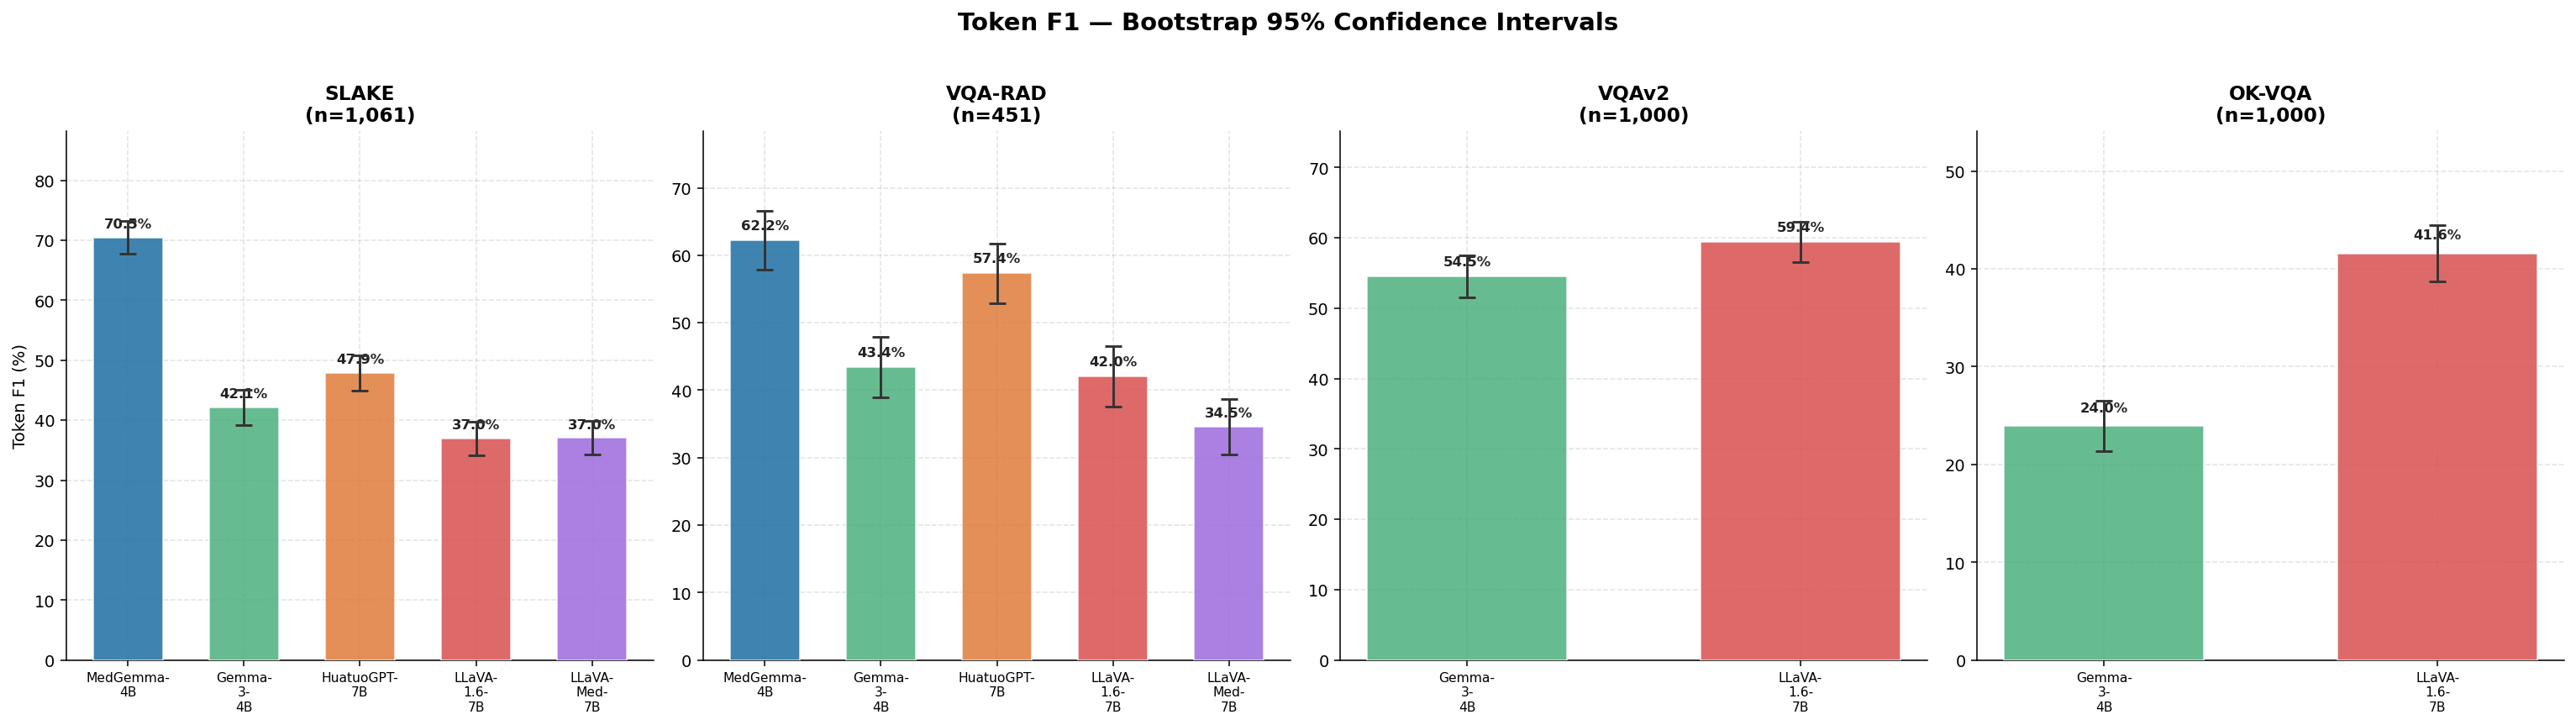

✓ Saved → results/fig1_f1_ci_bars.png


In [6]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=False)
fig.suptitle('Token F1 — Bootstrap 95% Confidence Intervals',
             fontsize=15, fontweight='bold', y=1.02)

for ax, (dataset, models_ci) in zip(axes, CI.items()):
    model_names = list(models_ci.keys())
    means  = [models_ci[m]['f1'][0] for m in model_names]
    lowers = [models_ci[m]['f1'][1] for m in model_names]
    uppers = [models_ci[m]['f1'][2] for m in model_names]
    errors_lo = [m - l for m, l in zip(means, lowers)]
    errors_hi = [u - m for m, u in zip(means, uppers)]

    colors = [MODEL_COLORS.get(m, '#888') for m in model_names]
    x = range(len(model_names))

    bars = ax.bar(x, means, color=colors, alpha=0.85, width=0.6,
                  zorder=3, edgecolor='white', linewidth=0.8)
    ax.errorbar(x, means,
                yerr=[errors_lo, errors_hi],
                fmt='none', color='#333', capsize=5, capthick=1.5,
                elinewidth=1.5, zorder=4)

    # Value labels on bars
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, mean + 1.2,
                f'{mean:.1f}%', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color='#222')

    n_samples = list(ALL_SCORES[dataset].values())[0]['n']
    ax.set_title(f'{dataset}\n(n={n_samples:,})', fontsize=12, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels([m.replace('-', '-\n') for m in model_names],
                       fontsize=8, rotation=0, ha='center')
    ax.set_ylabel('Token F1 (%)' if ax == axes[0] else '')
    ax.set_ylim(0, max(means) * 1.18 + 5)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'fig1_f1_ci_bars.png', bbox_inches='tight', dpi=160)
plt.show()
print('✓ Saved → results/fig1_f1_ci_bars.png')

## 5. CI Bar Charts — Judge Accuracy with 95% Error Bars

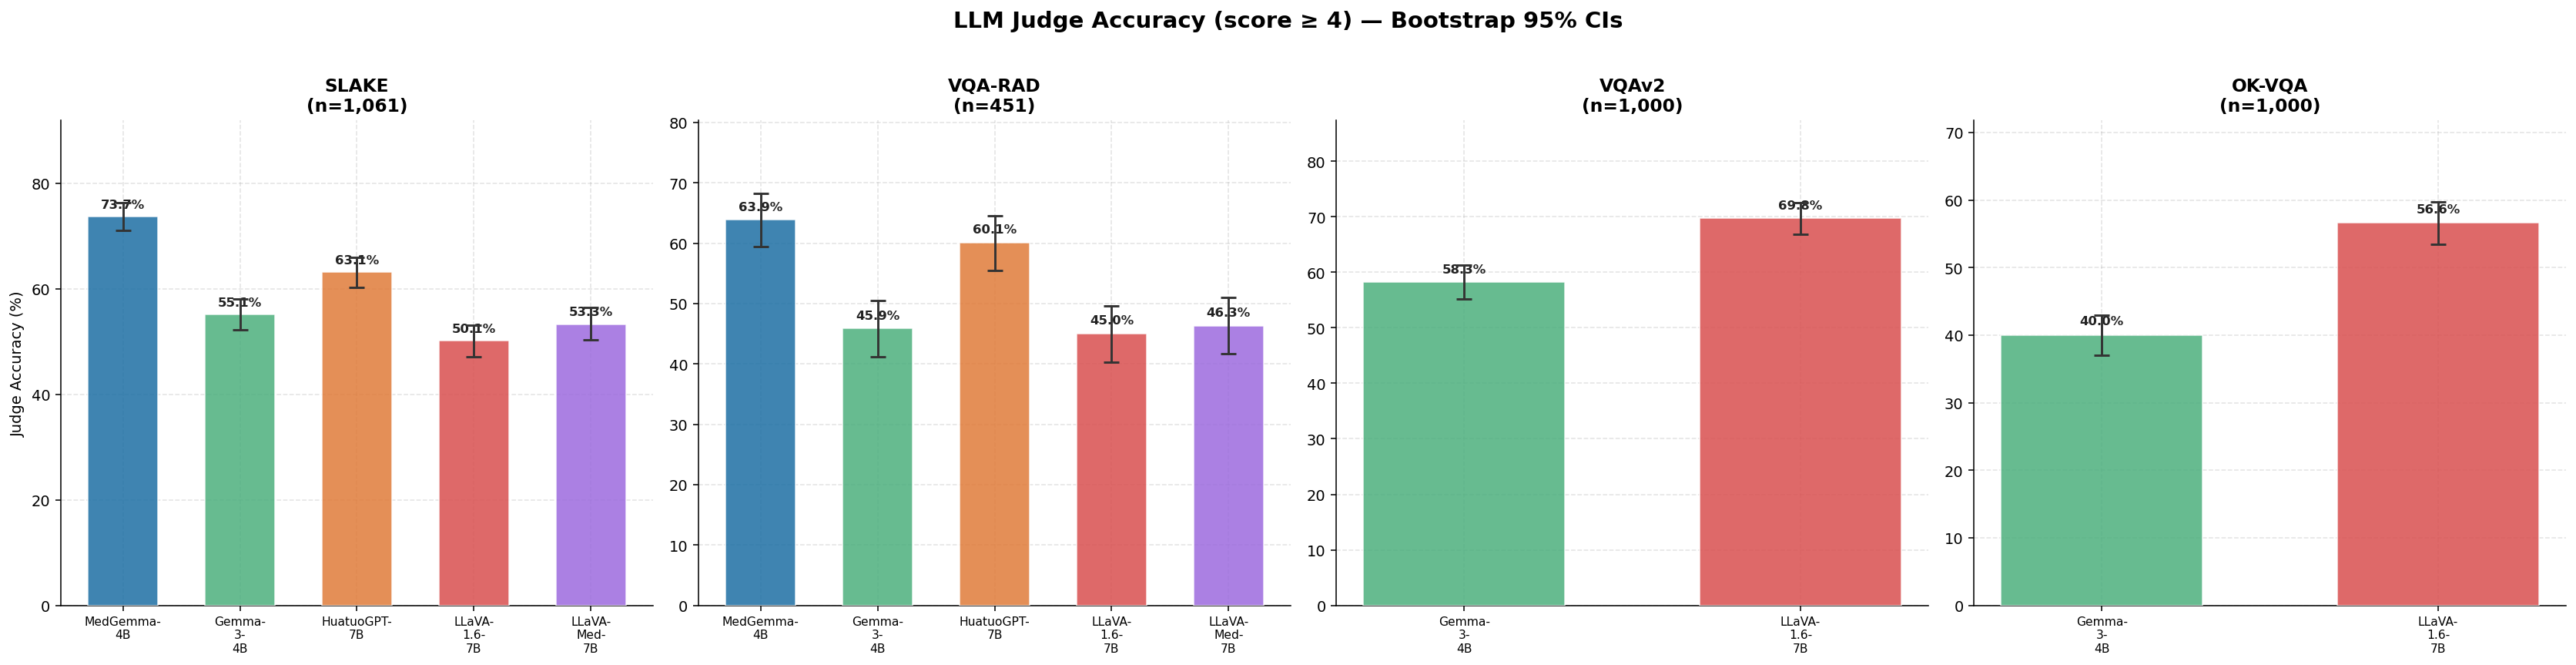

✓ Saved → results/fig2_judge_ci_bars.png


In [7]:
# Only datasets that have judge data
judge_datasets = {ds: m for ds, m in CI.items()
                  if any(v['judge'] is not None for v in m.values())}

ncols = len(judge_datasets)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 6), sharey=False)
if ncols == 1:
    axes = [axes]
fig.suptitle('LLM Judge Accuracy (score ≥ 4) — Bootstrap 95% CIs',
             fontsize=15, fontweight='bold', y=1.02)

for ax, (dataset, models_ci) in zip(axes, judge_datasets.items()):
    model_names = [m for m, c in models_ci.items() if c['judge'] is not None]
    means  = [models_ci[m]['judge'][0] for m in model_names]
    lowers = [models_ci[m]['judge'][1] for m in model_names]
    uppers = [models_ci[m]['judge'][2] for m in model_names]
    errors_lo = [m - l for m, l in zip(means, lowers)]
    errors_hi = [u - m for m, u in zip(means, uppers)]

    colors = [MODEL_COLORS.get(m, '#888') for m in model_names]
    x = range(len(model_names))

    bars = ax.bar(x, means, color=colors, alpha=0.85, width=0.6,
                  zorder=3, edgecolor='white', linewidth=0.8)
    ax.errorbar(x, means,
                yerr=[errors_lo, errors_hi],
                fmt='none', color='#333', capsize=5, capthick=1.5,
                elinewidth=1.5, zorder=4)

    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, mean + 1.2,
                f'{mean:.1f}%', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color='#222')

    n_samples = list(ALL_SCORES[dataset].values())[0]['n']
    ax.set_title(f'{dataset}\n(n={n_samples:,})', fontsize=12, fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels([m.replace('-', '-\n') for m in model_names],
                       fontsize=8, rotation=0, ha='center')
    ax.set_ylabel('Judge Accuracy (%)' if ax == axes[0] else '')
    ax.set_ylim(0, max(means) * 1.18 + 5)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'fig2_judge_ci_bars.png', bbox_inches='tight', dpi=160)
plt.show()
print('✓ Saved → results/fig2_judge_ci_bars.png')

## 6. Pairwise Paired Permutation Tests

In [8]:
print('Running paired permutation tests (n=10,000 permutations each)...')

PERM = {}  # {dataset: {'f1': {(A,B): p}, 'judge': {(A,B): p}}}

for dataset, models in ALL_SCORES.items():
    model_names = list(models.keys())
    perm_f1, perm_judge = {}, {}
    for m_a, m_b in combinations(model_names, 2):
        key = (m_a, m_b)
        perm_f1[key] = paired_permutation_test(
            models[m_a]['f1'], models[m_b]['f1'])
        ja, jb = models[m_a]['judge'], models[m_b]['judge']
        if ja is not None and jb is not None:
            perm_judge[key] = paired_permutation_test(ja, jb)
        else:
            perm_judge[key] = None
    PERM[dataset] = {'f1': perm_f1, 'judge': perm_judge}
    print(f'  ✓ {dataset} — {len(perm_f1)} pairs tested')

print('\n✓ All permutation tests complete.')

Running paired permutation tests (n=10,000 permutations each)...
  ✓ SLAKE — 10 pairs tested
  ✓ VQA-RAD — 10 pairs tested
  ✓ VQAv2 — 1 pairs tested
  ✓ OK-VQA — 1 pairs tested

✓ All permutation tests complete.


In [9]:
# ── Pretty-print results per dataset ─────────────────────────────────────────
for dataset in PERM:
    rows = []
    for (m_a, m_b), p in PERM[dataset]['f1'].items():
        delta = (CI[dataset][m_a]['f1'][0] - CI[dataset][m_b]['f1'][0])
        pj    = PERM[dataset]['judge'].get((m_a, m_b))
        rows.append({
            'Model A': m_a, 'Model B': m_b,
            'ΔF1 (pp)': f'{delta:+.2f}',
            'p (F1)':   f'{p:.4f}',
            'Sig (F1)': stars(p),
            'p (Judge)': f'{pj:.4f}' if pj is not None else '—',
            'Sig (Judge)': stars(pj) if pj is not None else '—',
        })
    df = pd.DataFrame(rows)
    print(f'\n### {dataset}')
    display(df.style.applymap(
        lambda v: 'color: #1d6fa4; font-weight:bold' if v == '***' else
                  ('color: #e07b39; font-weight:bold' if v == '**' else
                   ('color: #4caf7d' if v == '*' else
                    ('color: #aaa' if v == 'ns' else ''))),
        subset=['Sig (F1)', 'Sig (Judge)']
    ))


### SLAKE


,Model A,Model B,ΔF1 (pp),p (F1),Sig (F1),p (Judge),Sig (Judge)
0,MedGemma-4B,Gemma-3-4B,+28.37,0.0000,***,0.0000,***
1,MedGemma-4B,HuatuoGPT-7B,+22.64,0.0000,***,0.0000,***
2,MedGemma-4B,LLaVA-1.6-7B,+33.52,0.0000,***,0.0000,***
3,MedGemma-4B,LLaVA-Med-7B,+33.46,0.0000,***,0.0000,***
4,Gemma-3-4B,HuatuoGPT-7B,-5.73,0.0000,***,0.0000,***
5,Gemma-3-4B,LLaVA-1.6-7B,+5.16,0.0010,**,0.0019,**
6,Gemma-3-4B,LLaVA-Med-7B,+5.09,0.0008,***,0.3214,ns
7,HuatuoGPT-7B,LLaVA-1.6-7B,+10.88,0.0000,***,0.0000,***
8,HuatuoGPT-7B,LLaVA-Med-7B,+10.82,0.0000,***,0.0000,***
9,LLaVA-1.6-7B,LLaVA-Med-7B,-0.06,0.9630,ns,0.0631,ns



### VQA-RAD


,Model A,Model B,ΔF1 (pp),p (F1),Sig (F1),p (Judge),Sig (Judge)
0,MedGemma-4B,Gemma-3-4B,+18.80,0.0000,***,0.0000,***
1,MedGemma-4B,HuatuoGPT-7B,+4.78,0.0216,*,0.0672,ns
2,MedGemma-4B,LLaVA-1.6-7B,+20.16,0.0000,***,0.0000,***
3,MedGemma-4B,LLaVA-Med-7B,+27.66,0.0000,***,0.0000,***
4,Gemma-3-4B,HuatuoGPT-7B,-14.01,0.0000,***,0.0000,***
5,Gemma-3-4B,LLaVA-1.6-7B,+1.36,0.6137,ns,0.8101,ns
6,Gemma-3-4B,LLaVA-Med-7B,+8.86,0.0009,***,0.8133,ns
7,HuatuoGPT-7B,LLaVA-1.6-7B,+15.37,0.0000,***,0.0000,***
8,HuatuoGPT-7B,LLaVA-Med-7B,+22.88,0.0000,***,0.0000,***
9,LLaVA-1.6-7B,LLaVA-Med-7B,+7.50,0.0176,*,0.6416,ns



### VQAv2


,Model A,Model B,ΔF1 (pp),p (F1),Sig (F1),p (Judge),Sig (Judge)
0,Gemma-3-4B,LLaVA-1.6-7B,-4.93,0.0059,**,0.0000,***



### OK-VQA


,Model A,Model B,ΔF1 (pp),p (F1),Sig (F1),p (Judge),Sig (Judge)
0,Gemma-3-4B,LLaVA-1.6-7B,-17.64,0.0000,***,0.0000,***


## 7. P-value Heatmaps

Lower-triangular matrix — each cell shows the p-value (row model vs column model on F1).  
Cell colour: **blue** = highly significant, **white** = not significant.

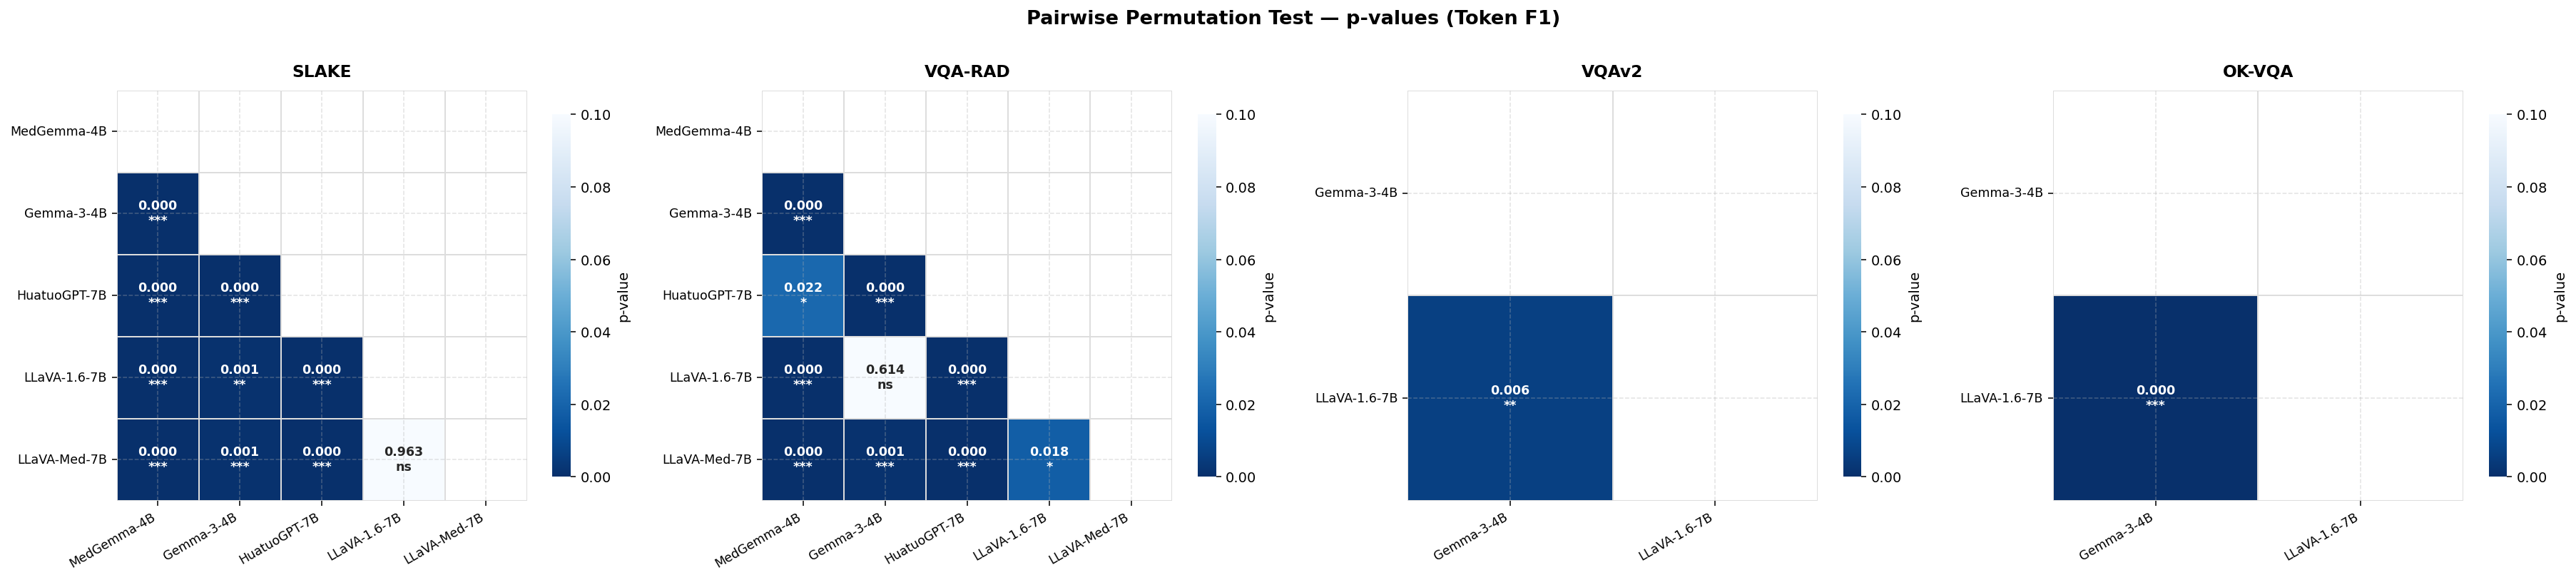

✓ Saved → results/fig3_pvalue_heatmaps.png


In [10]:
def build_pval_matrix(dataset):
    models = list(ALL_SCORES[dataset].keys())
    n = len(models)
    mat = np.full((n, n), np.nan)
    for i, m_a in enumerate(models):
        for j, m_b in enumerate(models):
            if i == j:
                continue
            key = (m_a, m_b) if (m_a, m_b) in PERM[dataset]['f1'] else (m_b, m_a)
            if key in PERM[dataset]['f1']:
                mat[i, j] = PERM[dataset]['f1'][key]
    return mat, models

# ── Datasets with ≥ 2 models ──────────────────────────────────────────────────
plot_ds = [ds for ds in PERM if len(ALL_SCORES[ds]) >= 2]
fig, axes = plt.subplots(1, len(plot_ds), figsize=(6.5 * len(plot_ds), 5.5))
if len(plot_ds) == 1:
    axes = [axes]

fig.suptitle('Pairwise Permutation Test — p-values (Token F1)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, dataset in zip(axes, plot_ds):
    mat, models = build_pval_matrix(dataset)

    # Mask upper triangle + diagonal
    mask = np.triu(np.ones_like(mat, dtype=bool))

    annot = np.full_like(mat, '', dtype=object)
    for i in range(len(models)):
        for j in range(len(models)):
            if not np.isnan(mat[i, j]) and not mask[i, j]:
                p = mat[i, j]
                annot[i, j] = f'{p:.3f}\n{stars(p)}'

    sns.heatmap(
        mat, ax=ax, mask=mask,
        cmap='Blues_r',        # reversed: low p → dark blue
        vmin=0, vmax=0.1,
        annot=annot, fmt='',
        annot_kws={'size': 9, 'weight': 'bold'},
        linewidths=0.8, linecolor='#ddd',
        cbar_kws={'label': 'p-value', 'shrink': 0.8},
        square=True
    )
    ax.set_title(dataset, fontsize=12, fontweight='bold', pad=10)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(models, rotation=0, fontsize=9)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'fig3_pvalue_heatmaps.png', bbox_inches='tight', dpi=160)
plt.show()
print('✓ Saved → results/fig3_pvalue_heatmaps.png')

## 8. ΔF1 Heatmaps Annotated with Significance Stars

Each cell = F1(row) − F1(column). Stars mark statistical significance.

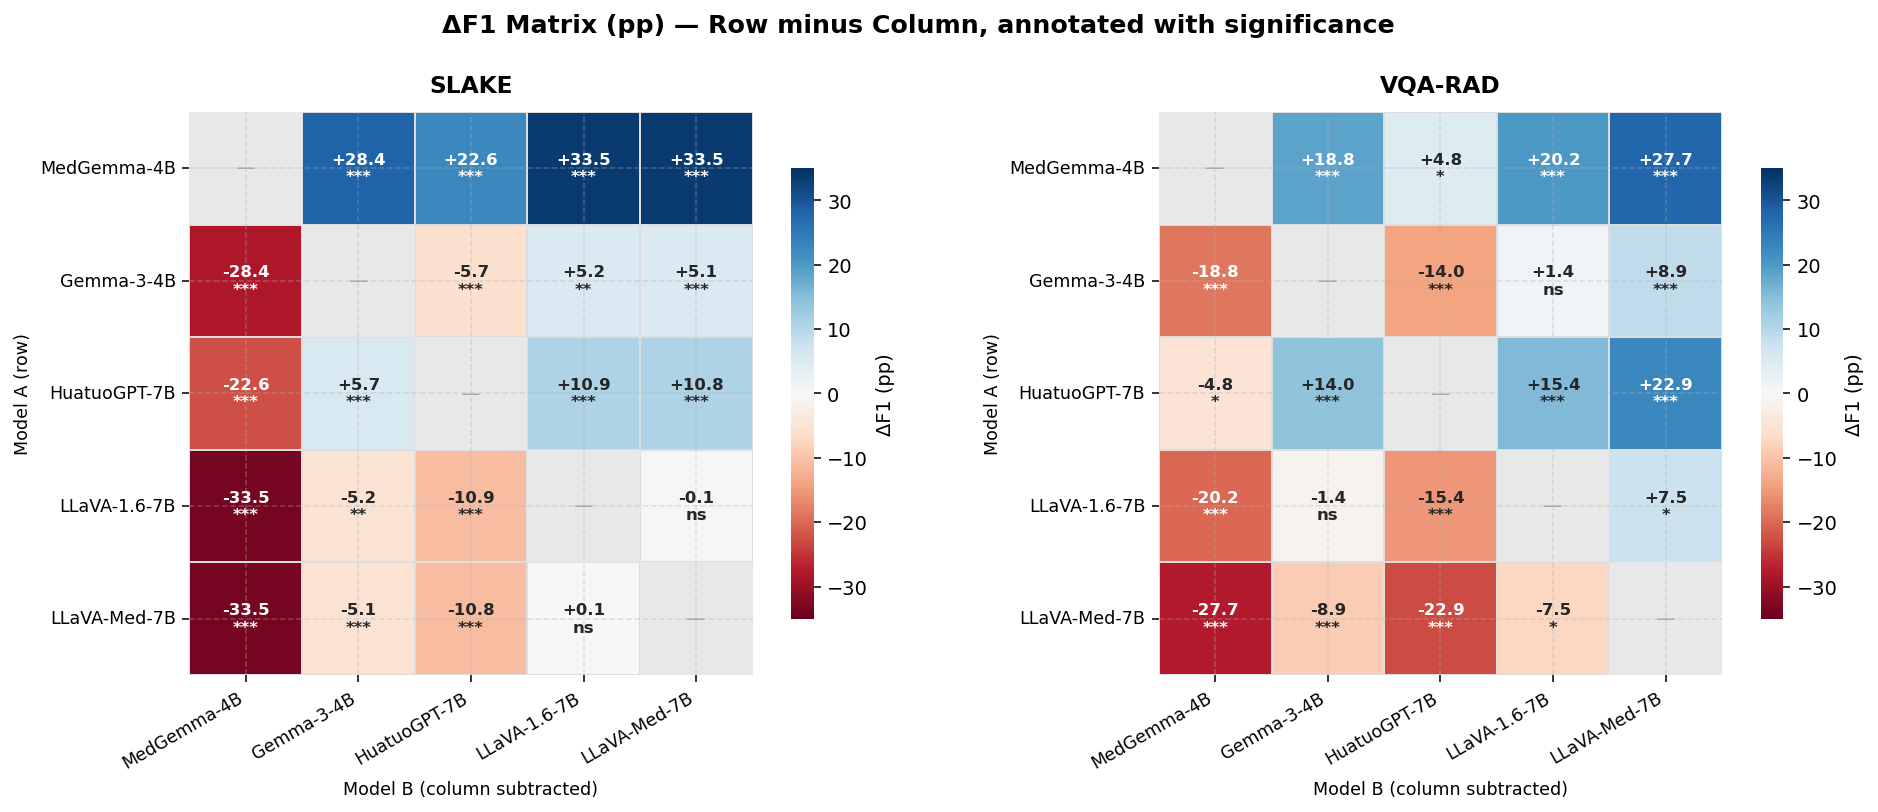

✓ Saved → results/fig4_delta_f1_heatmaps.png


In [11]:
def build_delta_matrix(dataset):
    models = list(ALL_SCORES[dataset].keys())
    n = len(models)
    delta_mat = np.zeros((n, n))
    annot_mat = np.full((n, n), '', dtype=object)
    for i, m_a in enumerate(models):
        for j, m_b in enumerate(models):
            if i == j:
                annot_mat[i, j] = '—'
                continue
            d = CI[dataset][m_a]['f1'][0] - CI[dataset][m_b]['f1'][0]
            delta_mat[i, j] = d
            key = (m_a, m_b) if (m_a, m_b) in PERM[dataset]['f1'] else (m_b, m_a)
            p   = PERM[dataset]['f1'].get(key, 1.0)
            annot_mat[i, j] = f'{d:+.1f}\n{stars(p)}'
    return delta_mat, annot_mat, models

# Only medical datasets (5-model) for readability
med_ds = [ds for ds in ['SLAKE', 'VQA-RAD'] if ds in PERM]
fig, axes = plt.subplots(1, len(med_ds), figsize=(7 * len(med_ds), 5.5))
if len(med_ds) == 1:
    axes = [axes]

fig.suptitle('ΔF1 Matrix (pp) — Row minus Column, annotated with significance',
             fontsize=13, fontweight='bold', y=1.02)

for ax, dataset in zip(axes, med_ds):
    delta_mat, annot_mat, models = build_delta_matrix(dataset)

    # Mask diagonal
    diag_mask = np.eye(len(models), dtype=bool)

    sns.heatmap(
        delta_mat, ax=ax,
        mask=diag_mask,
        cmap='RdBu',
        center=0, vmin=-35, vmax=35,
        annot=annot_mat, fmt='',
        annot_kws={'size': 8.5, 'weight': 'bold'},
        linewidths=0.8, linecolor='#ddd',
        cbar_kws={'label': 'ΔF1 (pp)', 'shrink': 0.8},
        square=True
    )
    # Fill diagonal with grey
    for i in range(len(models)):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True,
                                   color='#e8e8e8', lw=0))
        ax.text(i + 0.5, i + 0.5, '—', ha='center', va='center',
                fontsize=10, color='#aaa')

    ax.set_title(dataset, fontsize=12, fontweight='bold', pad=10)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
    ax.set_yticklabels(models, rotation=0, fontsize=9)
    ax.set_xlabel('Model B (column subtracted)', fontsize=9)
    ax.set_ylabel('Model A (row)', fontsize=9)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'fig4_delta_f1_heatmaps.png', bbox_inches='tight', dpi=160)
plt.show()
print('✓ Saved → results/fig4_delta_f1_heatmaps.png')

## 9. Cross-Dataset F1 Comparison (Models Available on Both Medical Datasets)

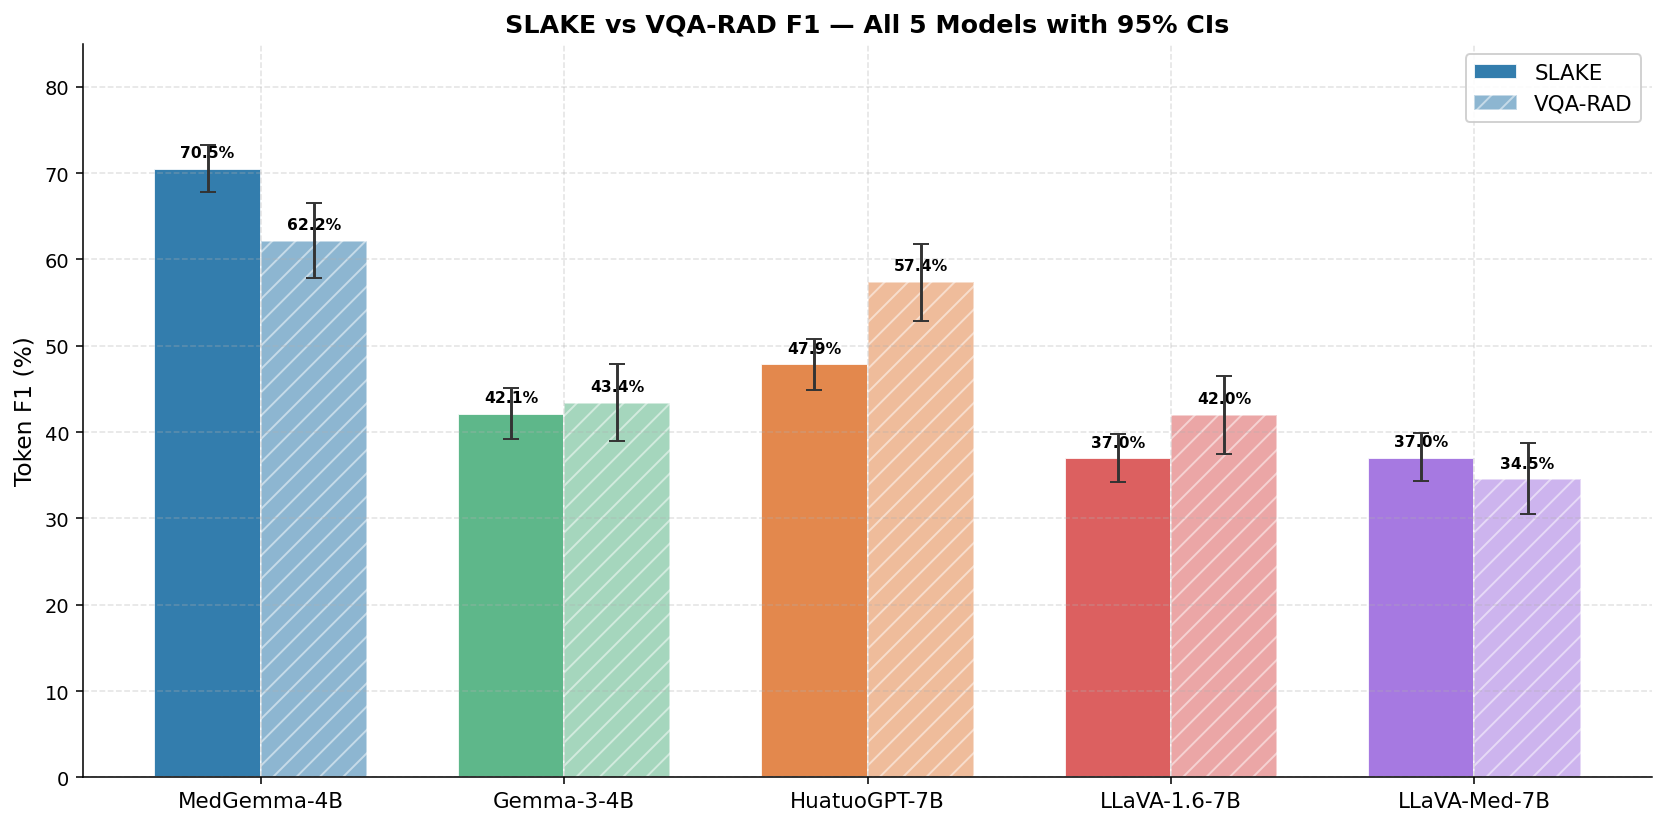

✓ Saved → results/fig5_cross_dataset_comparison.png


In [12]:
# Models that appear in both SLAKE and VQA-RAD
shared = [m for m in ALL_SCORES['SLAKE'] if m in ALL_SCORES['VQA-RAD']]

slake_means  = [CI['SLAKE'][m]['f1'][0]   for m in shared]
slake_lo     = [CI['SLAKE'][m]['f1'][0] - CI['SLAKE'][m]['f1'][1]  for m in shared]
slake_hi     = [CI['SLAKE'][m]['f1'][2] - CI['SLAKE'][m]['f1'][0]  for m in shared]
vrad_means   = [CI['VQA-RAD'][m]['f1'][0] for m in shared]
vrad_lo      = [CI['VQA-RAD'][m]['f1'][0] - CI['VQA-RAD'][m]['f1'][1] for m in shared]
vrad_hi      = [CI['VQA-RAD'][m]['f1'][2] - CI['VQA-RAD'][m]['f1'][0] for m in shared]

x = np.arange(len(shared))
width = 0.35
colors = [MODEL_COLORS.get(m, '#888') for m in shared]

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, slake_means, width, label='SLAKE',
               color=colors, alpha=0.9, edgecolor='white')
bars2 = ax.bar(x + width/2, vrad_means,  width, label='VQA-RAD',
               color=colors, alpha=0.5, edgecolor='white', hatch='//')

ax.errorbar(x - width/2, slake_means, yerr=[slake_lo, slake_hi],
            fmt='none', color='#333', capsize=4, elinewidth=1.5, zorder=5)
ax.errorbar(x + width/2, vrad_means,  yerr=[vrad_lo,  vrad_hi],
            fmt='none', color='#333', capsize=4, elinewidth=1.5, zorder=5)

for bars, means in [(bars1, slake_means), (bars2, vrad_means)]:
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, mean + 1.0,
                f'{mean:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(shared, fontsize=11)
ax.set_ylabel('Token F1 (%)', fontsize=12)
ax.set_title('SLAKE vs VQA-RAD F1 — All 5 Models with 95% CIs',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9)
ax.set_ylim(0, 85)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'fig5_cross_dataset_comparison.png', bbox_inches='tight', dpi=160)
plt.show()
print('✓ Saved → results/fig5_cross_dataset_comparison.png')

## 10. Key Findings Summary

In [13]:
print('=' * 72)
print('KEY STATISTICAL FINDINGS')
print('=' * 72)

findings = [
    ('SLAKE',   'LLaVA-1.6-7B', 'LLaVA-Med-7B', 'F1'),
    ('VQA-RAD', 'MedGemma-4B',  'HuatuoGPT-7B', 'F1'),
    ('VQA-RAD', 'MedGemma-4B',  'HuatuoGPT-7B', 'Judge'),
    ('VQA-RAD', 'Gemma-3-4B',   'LLaVA-1.6-7B', 'F1'),
    ('SLAKE',   'Gemma-3-4B',   'LLaVA-Med-7B', 'Judge'),
    ('OK-VQA',  'LLaVA-1.6-7B', 'Gemma-3-4B',   'F1'),
]

for dataset, m_a, m_b, metric in findings:
    if m_a not in ALL_SCORES.get(dataset, {}) or m_b not in ALL_SCORES.get(dataset, {}):
        continue
    key = (m_a, m_b) if (m_a, m_b) in PERM[dataset]['f1'] else (m_b, m_a)

    if metric == 'F1':
        p     = PERM[dataset]['f1'].get(key, None)
        delta = CI[dataset][m_a]['f1'][0] - CI[dataset][m_b]['f1'][0]
        m_ci  = CI[dataset][m_a]['f1']
        b_ci  = CI[dataset][m_b]['f1']
        print(f'\n[{dataset}] {m_a} vs {m_b} — Token F1')
        print(f'  {m_a:<18} {m_ci[0]:.2f}% CI [{m_ci[1]:.2f}%, {m_ci[2]:.2f}%]')
        print(f'  {m_b:<18} {b_ci[0]:.2f}% CI [{b_ci[1]:.2f}%, {b_ci[2]:.2f}%]')
        print(f'  Δ = {delta:+.2f} pp  |  p = {p:.4f}  |  {stars(p)}')
    else:
        p     = PERM[dataset]['judge'].get(key, None)
        if p is None:
            continue
        ja    = CI[dataset][m_a]['judge']
        jb    = CI[dataset][m_b]['judge']
        delta = ja[0] - jb[0]
        print(f'\n[{dataset}] {m_a} vs {m_b} — Judge Accuracy')
        print(f'  {m_a:<18} {ja[0]:.2f}% CI [{ja[1]:.2f}%, {ja[2]:.2f}%]')
        print(f'  {m_b:<18} {jb[0]:.2f}% CI [{jb[1]:.2f}%, {jb[2]:.2f}%]')
        print(f'  Δ = {delta:+.2f} pp  |  p = {p:.4f}  |  {stars(p)}')

print('\n' + '=' * 72)
print('Significance: *** p<0.001  ** p<0.01  * p<0.05  ns p≥0.05')
print('Method: 10,000-resample bootstrap CIs; 10,000-permutation two-sided test (seed=42)')

KEY STATISTICAL FINDINGS

[SLAKE] LLaVA-1.6-7B vs LLaVA-Med-7B — Token F1
  LLaVA-1.6-7B       36.98% CI [34.17%, 39.80%]
  LLaVA-Med-7B       37.04% CI [34.29%, 39.89%]
  Δ = -0.06 pp  |  p = 0.9630  |  ns

[VQA-RAD] MedGemma-4B vs HuatuoGPT-7B — Token F1
  MedGemma-4B        62.19% CI [57.88%, 66.52%]
  HuatuoGPT-7B       57.40% CI [52.92%, 61.77%]
  Δ = +4.78 pp  |  p = 0.0216  |  *

[VQA-RAD] MedGemma-4B vs HuatuoGPT-7B — Judge Accuracy
  MedGemma-4B        63.86% CI [59.42%, 68.29%]
  HuatuoGPT-7B       60.09% CI [55.43%, 64.52%]
  Δ = +3.77 pp  |  p = 0.0672  |  ns

[VQA-RAD] Gemma-3-4B vs LLaVA-1.6-7B — Token F1
  Gemma-3-4B         43.39% CI [38.94%, 47.86%]
  LLaVA-1.6-7B       42.03% CI [37.52%, 46.54%]
  Δ = +1.36 pp  |  p = 0.6137  |  ns

[SLAKE] Gemma-3-4B vs LLaVA-Med-7B — Judge Accuracy
  Gemma-3-4B         55.14% CI [52.21%, 58.15%]
  LLaVA-Med-7B       53.35% CI [50.33%, 56.46%]
  Δ = +1.79 pp  |  p = 0.3214  |  ns

[OK-VQA] LLaVA-1.6-7B vs Gemma-3-4B — Token F1
  LLaV

## 11. Export Results
Saves the full CI + p-value table to `results/statistical_significance_results.json` and a CSV for easy sharing.

In [14]:
# ── Build export dict ─────────────────────────────────────────────────────────
export = {}
for dataset in CI:
    export[dataset] = {
        'ci': {
            model: {
                'f1': list(c['f1']),
                'judge': list(c['judge']) if c['judge'] else None
            }
            for model, c in CI[dataset].items()
        },
        'perm_f1':    {f'{a} vs {b}': float(p)
                       for (a, b), p in PERM[dataset]['f1'].items()},
        'perm_judge': {f'{a} vs {b}': float(p) if p is not None else None
                       for (a, b), p in PERM[dataset]['judge'].items()},
    }

json_path = RESULTS_DIR / 'statistical_significance_results.json'
json_path.write_text(json.dumps(export, indent=2))
print(f'✓ JSON exported → {json_path}')

# ── CSV export ────────────────────────────────────────────────────────────────
csv_rows = []
for dataset, models in CI.items():
    for model, c in models.items():
        m, lo, hi = c['f1']
        j = c['judge']
        csv_rows.append({
            'dataset': dataset, 'model': model,
            'f1_mean': round(m, 4), 'f1_ci_lo': round(lo, 4), 'f1_ci_hi': round(hi, 4),
            'judge_acc_mean': round(j[0], 4) if j else None,
            'judge_ci_lo':    round(j[1], 4) if j else None,
            'judge_ci_hi':    round(j[2], 4) if j else None,
        })

csv_path = RESULTS_DIR / 'ci_results.csv'
pd.DataFrame(csv_rows).to_csv(csv_path, index=False)
print(f'✓ CSV exported  → {csv_path}')

print('\nAll outputs saved to results/')

✓ JSON exported → /Users/shriyanshraj/vlm_benchmark/results/statistical_significance_results.json
✓ CSV exported  → /Users/shriyanshraj/vlm_benchmark/results/ci_results.csv

All outputs saved to results/
